In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.2 MB/s eta 0:00:00


# Connect Google drive

In [2]:
# Connect google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define paths
# --- Define your paths ---
PATH_TO_X_TRAIN = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/images_train'
PATH_TO_Y_TRAIN = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/binary_masks_train'

PATH_TO_X_VAL = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/imges_val'
PATH_TO_Y_VAL = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/binary_mask_val'

model_save_path = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Model_weights/segmentation_resnet18.pth'

In [11]:
# Import libraries

import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator

import torch
from torch.utils.data import Dataset, DataLoader
import os
import cv2
import numpy as np
from skimage.color import rgb2lab

import segmentation_models_pytorch as smp
import torch.nn as nn
import matplotlib.pyplot as plt

# Plott loss accuracy and dice co-efficient

In [ ]:
class PlotLossProgress:
    def __init__(self):
        self.epochs = []
        self.losses = []
        self.val_losses = []
        self.train_dice = []
        self.val_dice = []

    def update(self, epoch, train_loss, val_loss, train_dice, val_dice):
        self.epochs.append(epoch)
        self.losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.train_dice.append(train_dice)
        self.val_dice.append(val_dice)

        # Clear the previous plot for live updating
        clear_output(wait=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # --- Plot 1: Loss ---
        ax1.plot(self.epochs, self.losses, label="Train Loss", marker='o', color='tab:blue')
        ax1.plot(self.epochs, self.val_losses, label="Validation Loss", marker='o', color='tab:orange')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss (MSE)')
        ax1.set_title('Training & Validation Loss')
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

        # --- Plot 2: Dice Accuracy ---
        ax2.plot(self.epochs, self.train_dice, label="Train Dice", marker='s', color='tab:green')
        ax2.plot(self.epochs, self.val_dice, label="Validation Dice", marker='s', color='tab:red')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Dice Coefficient')
        ax2.set_title('Segmentation Accuracy (Dice)')
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

        plt.tight_layout()
        plt.show()

In [ ]:
def get_dice_coefficient(outputs, targets, threshold=0.5):
    preds = (outputs > threshold).float()
    targets = (targets > threshold).float()
    smooth = 1e-6
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean().item()

# Custom Datagenerator

In [5]:
class SegmentationDataset(Dataset):
    def __init__(self, path_X, path_Y, image_size=256):
        self.path_X = path_X
        self.path_Y = path_Y
        self.image_size = image_size

        # 1. Get all input files (e.g., '010_2HC.png')
        # We use the filename without extension as the unique key
        self.files_x = {os.path.splitext(f)[0]: f for f in os.listdir(path_X)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))}

        # 2. Get all mask files (e.g., '010_2HC_Annotation.png')
        # We strip '_Annotation' to see if it matches a key in files_x
        raw_masks = [f for f in os.listdir(path_Y) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.files_y = {}
        for f in raw_masks:
            name_without_ext = os.path.splitext(f)[0]
            # Remove the '_Annotation' suffix to get the matching ID
            match_id = name_without_ext.replace('_Annotation', '')
            self.files_y[match_id] = f

        # 3. Intersection: Only IDs that exist in both sets
        self.common_ids = sorted(list(set(self.files_x.keys()) & set(self.files_y.keys())))

        print(f"Match successful! Found {len(self.common_ids)} pairs.")
        if len(self.common_ids) > 0:
            print(f"Example Match: Input '{self.files_x[self.common_ids[0]]}' <---> Mask '{self.files_y[self.common_ids[0]]}'")

    def __len__(self):
        return len(self.common_ids)

    def _process_image(self, path):
        img = cv2.imread(path)
        if img is None: raise FileNotFoundError(f"Could not read {path}")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (self.image_size, self.image_size))
        lab = rgb2lab(img_rgb).astype(np.float32)
        l_channel = lab[:, :, 0] / 100.0
        return torch.from_numpy(l_channel).float().unsqueeze(0)

    def __getitem__(self, index):
        sample_id = self.common_ids[index]
        X = self._process_image(os.path.join(self.path_X, self.files_x[sample_id]))
        Y = self._process_image(os.path.join(self.path_Y, self.files_y[sample_id]))
        return X, Y

# ResNet-18 model

In [ ]:
# 1. Initialize the Transfer Learning Model
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=1,                  # 1 channel input
    classes=1,                      # 1 channel output
    activation='sigmoid'            # Output scaled to [0, 1]
)

# 2. Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Criterion Adjustment
# Since you've switched to Sigmoid (0 to 1 range), ensure your
# target labels are also normalized to [0, 1] for MSELoss.
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Model initialized with Sigmoid activation.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Model initialized with Sigmoid activation.


# Load Datagen and verify it

In [7]:
batch = 4

# --- Initialize the Datasets ---
train_dataset = SegmentationDataset(
    path_X=PATH_TO_X_TRAIN,
    path_Y=PATH_TO_Y_TRAIN,
    image_size=256
)

val_dataset = SegmentationDataset(
    path_X=PATH_TO_X_VAL,
    path_Y=PATH_TO_Y_VAL,
    image_size=256
)

# --- Initialize the DataLoaders ---
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch,
    shuffle=True,       # Shuffle training data to improve generalization
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch,       # Can be larger than training batch_size if memory allows
    shuffle=False,      # No need to shuffle validation data
    num_workers=4,
    pin_memory=True
)

Match successful! Found 422 pairs.
Example Match: Input '000_HC.png' <---> Mask '000_HC_Annotation.png'
Match successful! Found 200 pairs.
Example Match: Input '343_HC.png' <---> Mask '343_HC_Annotation.png'


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [8]:
X_train, Y_train = next(iter(train_loader))

print(f"Batch X_train Shape: {X_train.shape}")
print(f"Batch Y_train Shape: {Y_train.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch X_train Shape: torch.Size([4, 1, 256, 256])
Batch Y_train Shape: torch.Size([4, 1, 256, 256])


In [9]:
# Get one batch from the loader
X_test, Y_test = next(iter(train_loader))

print(f"Batch X_test Shape: {X_test.shape}")
# Expected: torch.Size([16, 1, 256, 256]) -> [Batch, Channel, Height, Width]

print(f"Batch Y_test Shape: {Y_test.shape}")
# Expected: torch.Size([16, 3, 256, 256]) -> [Batch, Channel, Height, Width]

Batch X_test Shape: torch.Size([4, 1, 256, 256])
Batch Y_test Shape: torch.Size([4, 1, 256, 256])


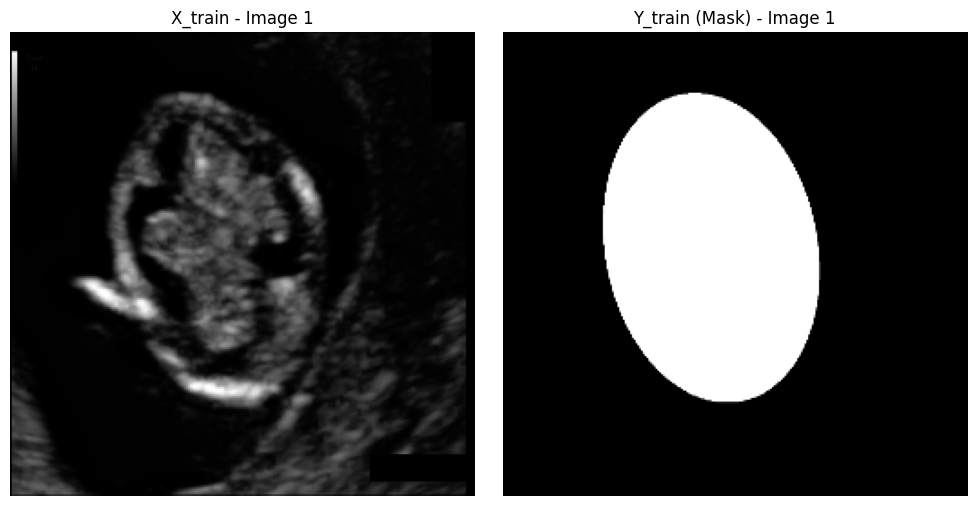

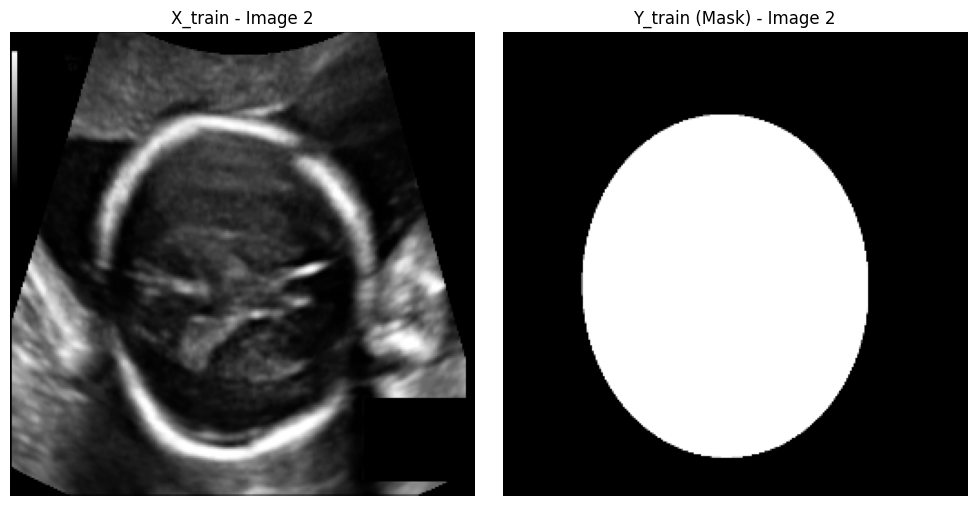

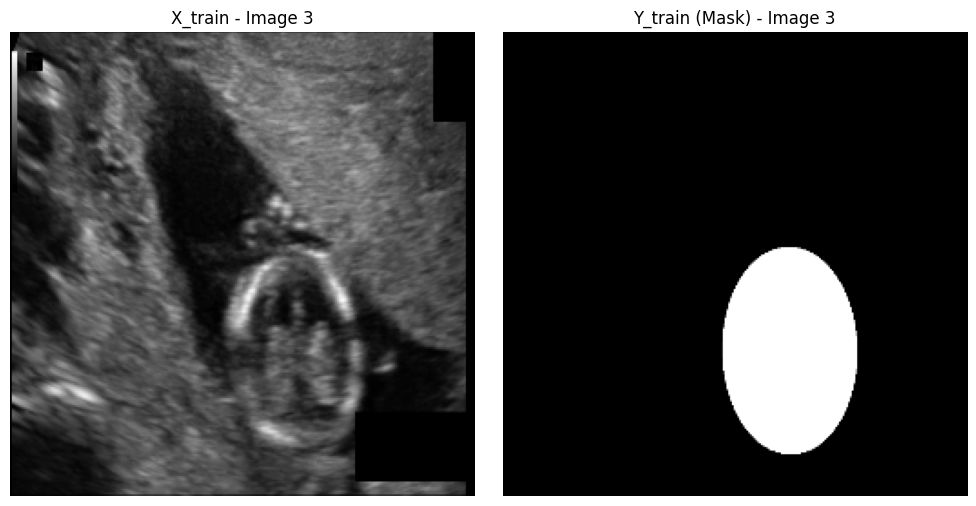

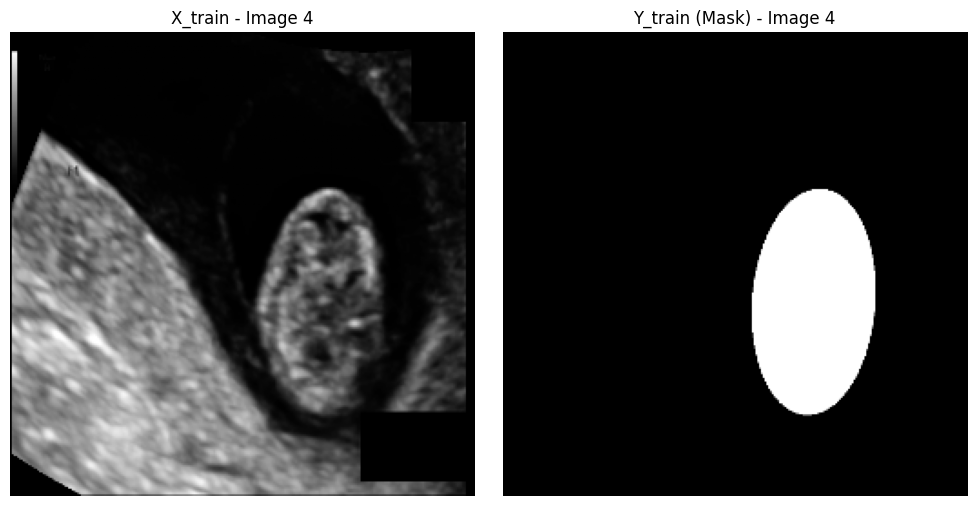

In [10]:
# Assuming X_train and Y_train are already loaded from the previous cell
# X_train, Y_train = next(iter(train_loader))

num_images_to_display = X_train.shape[0] # Display all images in the batch

for i in range(num_images_to_display):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display X_train image
    x_img = X_train[i].squeeze().cpu().numpy() # Remove batch and channel dimensions, move to CPU, convert to numpy
    axes[0].imshow(x_img, cmap='gray')
    axes[0].set_title(f'X_train - Image {i+1}')
    axes[0].axis('off')

    # Display Y_train (mask) image
    y_img = Y_train[i].squeeze().cpu().numpy() # Remove batch and channel dimensions, move to CPU, convert to numpy
    axes[1].imshow(y_img, cmap='gray') # Masks are typically grayscale
    axes[1].set_title(f'Y_train (Mask) - Image {i+1}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Batch X_val Shape: torch.Size([4, 1, 256, 256])
Batch Y_val Shape: torch.Size([4, 1, 256, 256])


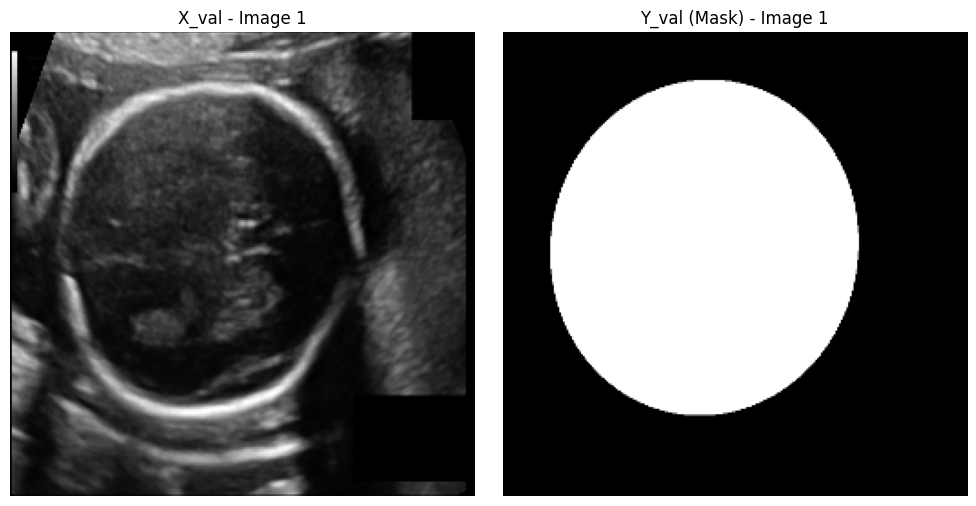

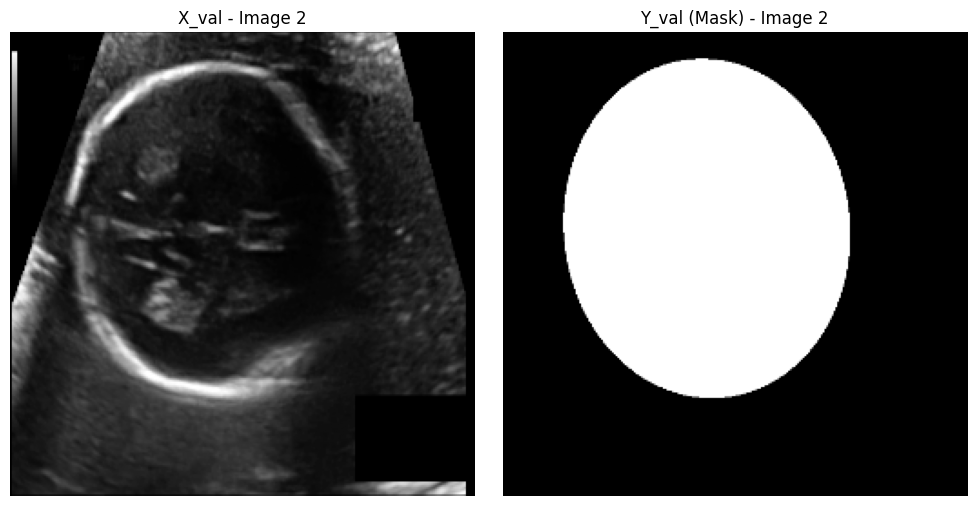

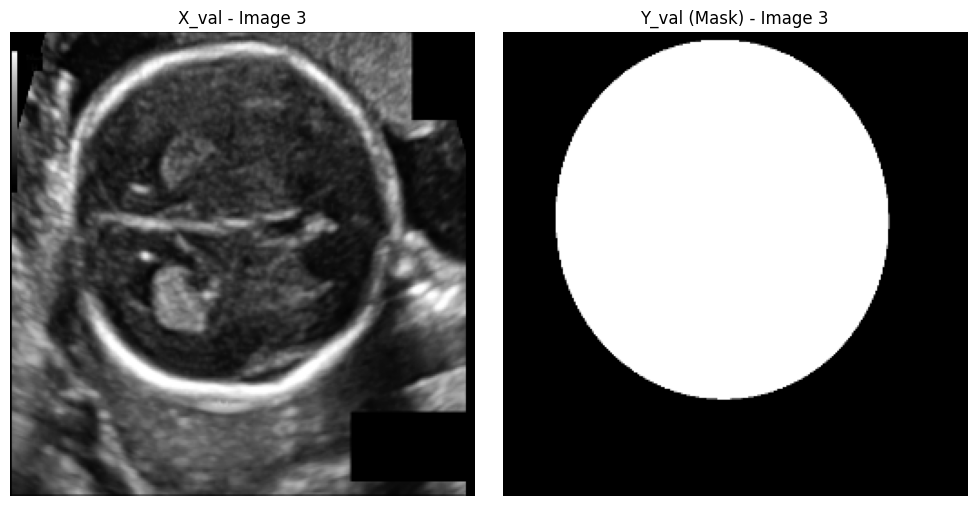

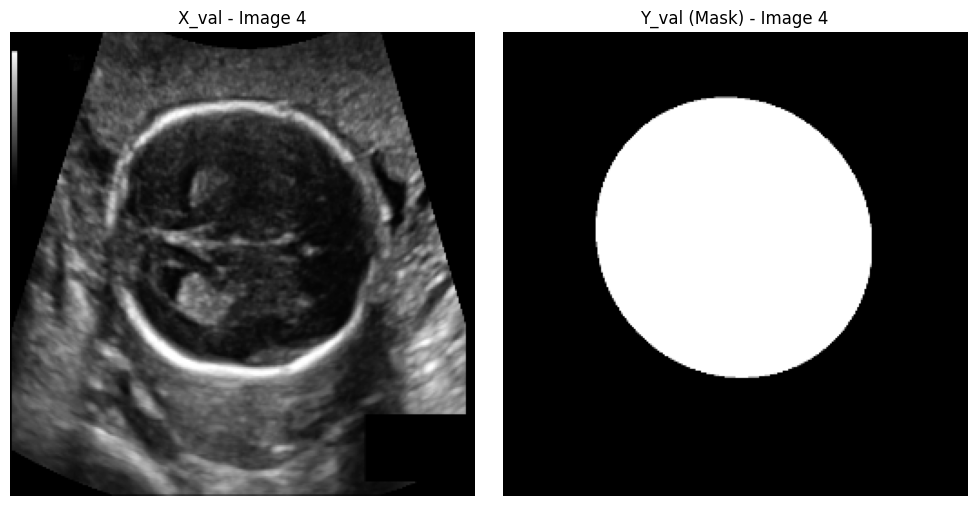

In [ ]:
# Get one batch from the validation loader
X_val, Y_val = next(iter(val_loader))

print(f"Batch X_val Shape: {X_val.shape}")
print(f"Batch Y_val Shape: {Y_val.shape}")

num_images_to_display = X_val.shape[0] # Display all images in the batch

for i in range(num_images_to_display):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display X_val image
    x_img = X_val[i].squeeze().cpu().numpy()
    axes[0].imshow(x_img, cmap='gray')
    axes[0].set_title(f'X_val - Image {i+1}')
    axes[0].axis('off')

    # Display Y_val (mask) image
    y_img = Y_val[i].squeeze().cpu().numpy()
    axes[1].imshow(y_img, cmap='gray') # Masks are typically grayscale
    axes[1].set_title(f'Y_val (Mask) - Image {i+1}')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

Using device: cuda


# Train the model

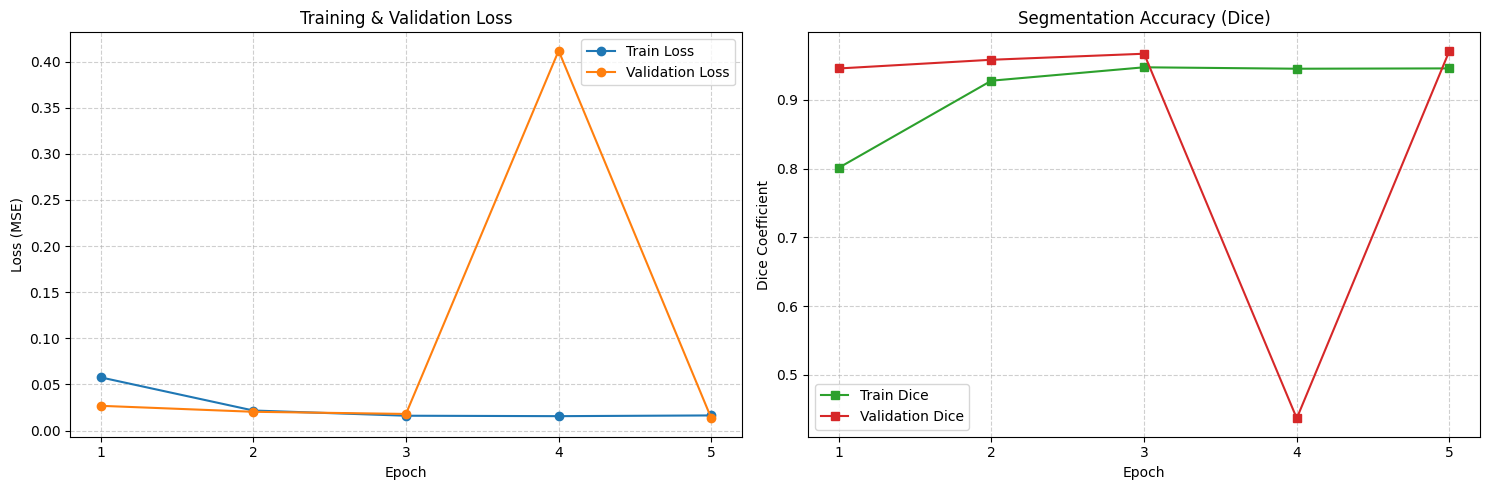

Training complete!


In [ ]:
num_epochs = 5
plot_progress = PlotLossProgress()

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    running_loss, running_dice = 0.0, 0.0
    for X_batch, Y_batch in train_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_dice += get_dice_coefficient(outputs, Y_batch)

    train_loss = running_loss / len(train_loader)
    train_dice = running_dice / len(train_loader)

    # --- Validation ---
    model.eval()
    val_running_loss, val_running_dice = 0.0, 0.0
    with torch.no_grad():
        for X_val_batch, Y_val_batch in val_loader:
            X_val_batch, Y_val_batch = X_val_batch.to(device), Y_val_batch.to(device)
            val_outputs = model(X_val_batch)

            v_loss = criterion(val_outputs, Y_val_batch)
            val_running_loss += v_loss.item()
            val_running_dice += get_dice_coefficient(val_outputs, Y_val_batch)

    val_loss_avg = val_running_loss / len(val_loader)
    val_dice_avg = val_running_dice / len(val_loader)

    # Update the live plot with all 4 metrics
    plot_progress.update(epoch + 1, train_loss, val_loss_avg, train_dice, val_dice_avg)

print("Training complete!")

# Save the model

In [ ]:
model_save_path = '/content/drive/MyDrive/Seg_collab/Seg_original/segmentation_resnet18.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, model_save_path)

print(f"Model and optimizer states saved to {model_save_path}")

Model and optimizer states saved to /content/drive/MyDrive/Seg_collab/Seg_original/segmentation_resnet18.pth
